In [2]:
import numpy as np  
import matplotlib.pyplot as plt 
import sklearn 
from random import sample
from scipy.stats import norm 


Quick data exploration


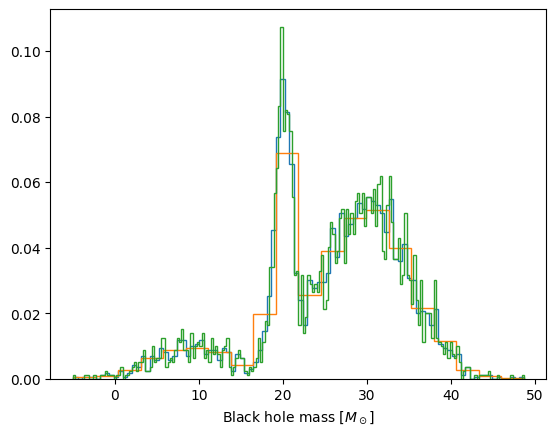

In [3]:
data=np.load("formationchannels.npy")
plt.hist(data, 100, density=True, histtype='step')
plt.hist(data, 20, density=True, histtype='step')
plt.hist(data, 200, density=True, histtype='step')    
plt.xlabel("Black hole mass $[M_\odot]$")
plt.show()              # maybe three modes

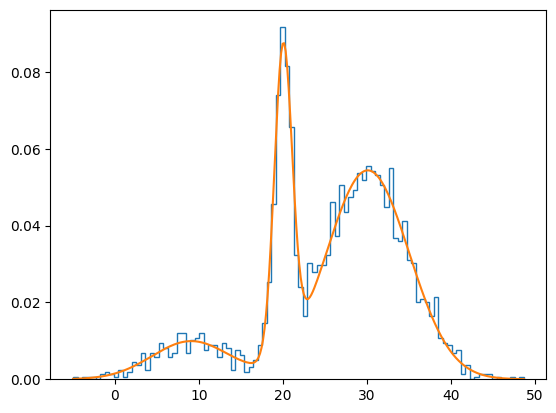

In [4]:
x=np.linspace(np.min(data), np.max(data),300)
gm = sklearn.mixture.GaussianMixture(n_components=3).fit(data)          #I define the model and .fit 

plt.hist(data, 100, density=True, histtype='step')

# Compute the log-likelihood of each sample (that is the probability given the determined parameters)
# It is a normalized LogLikelihood!
Log_prob=gm.score_samples((x.reshape(-1, 1)))                          
pdf = np.exp(Log_prob)

plt.plot(x,pdf)
plt.show; 

Model selection with AIC

In [5]:
Num_gauss = np.arange(1, 10)            #number of gaussians

#different models with different number of gaussians
models=[sklearn.mixture.GaussianMixture(Nu).fit(data) for Nu in Num_gauss]


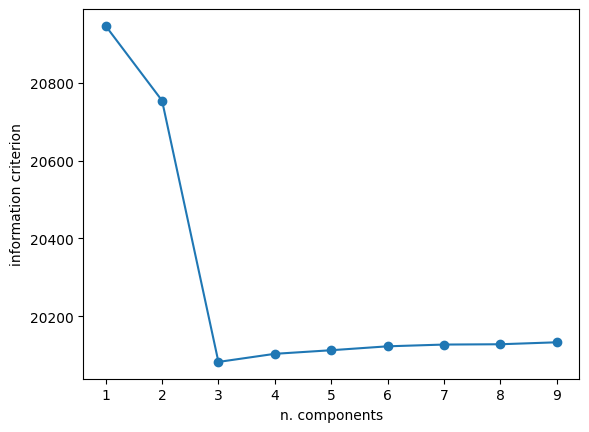

In [6]:
AIC = [m.aic(data) for m in models]
plt.plot(Num_gauss, AIC,)
plt.scatter(Num_gauss, AIC)

plt.xlabel('n. components')
plt.ylabel('information criterion');

As expected the minimum of the AIC is in n=3

In [7]:
# Index of the minimum value 
NG=np.argmin(AIC) +1 
NG

3

Comparing some results 


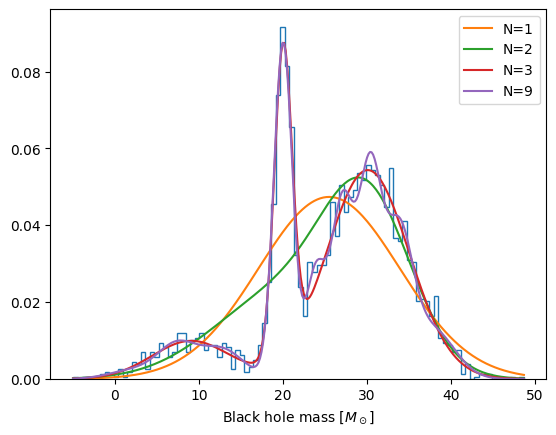

In [8]:
plt.hist(data, 100, density=True, histtype='step')

# plot the min of AIC, one and two before, three and six after  
for index in np.argmin(AIC)+np.array([-2,-1,0,6]):

    logprob = models[index].score_samples(x.reshape(-1, 1))
    plt.plot(x, np.exp(logprob),label='N='+str(Num_gauss[index]))

plt.xlabel("Black hole mass $[M_\odot]$")
plt.legend();

### Gaussian mode - Class labels  ###
Probability of coming from a given channel


predict_proba returns the responsabiity


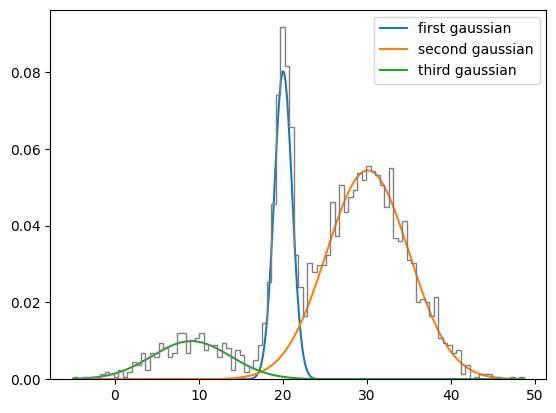

In [ ]:

#Density of each Gaussian component for each sample in X.
#For each sample the value of the first, the second and the third gaussian
pdf_value=gm.predict_proba((x.reshape(-1, 1)))

plt.plot(x,pdf_value[:,0]*pdf, label="first gaussian") #each weight multiply for the total gaussian 
plt.plot(x,pdf_value[:,1]*pdf, label="second gaussian")
plt.plot(x,pdf_value[:,2]*pdf, label="third gaussian")

plt.hist(data, 100, density=True, histtype='step', color='grey')
plt.legend()
plt.plot()
plt.show()

In [19]:
m=20         #given a bh of mass m
print("prob 1st gaussian", gm.predict_proba([[m]])[0,0])
print("prob 2st gaussian", gm.predict_proba([[m]])[0,1])
print("prob 3st gaussian", gm.predict_proba([[m]])[0,2])    

prob 1st gaussian 0.9177557791253893
prob 2st gaussian 0.07478980576433565
prob 3st gaussian 0.0074544151102748256
